# Google Reviews Word Cloud Analysis

Analyze positive and negative reviews using word clouds.

In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv('data/google_reviews_en.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   userName       500 non-null    str  
 1   at             500 non-null    str  
 2   content        500 non-null    str  
 3   score          500 non-null    int64
 4   thumbsUpCount  500 non-null    int64
dtypes: int64(2), str(3)
memory usage: 19.7 KB


## Data Preparation

In [2]:
df_hi = df[df['score']>=4]
df_lo = df[df['score']<4]

list_reviews_lo = df_lo['content'].astype(str).str.lower()
list_reviews_hi = df_hi['content'].astype(str).str.lower()

reviews_lo = ' '.join(list_reviews_lo)
reviews_hi = ' '.join(list_reviews_hi)

## Word Cloud: Negative Reviews (< 4 stars)

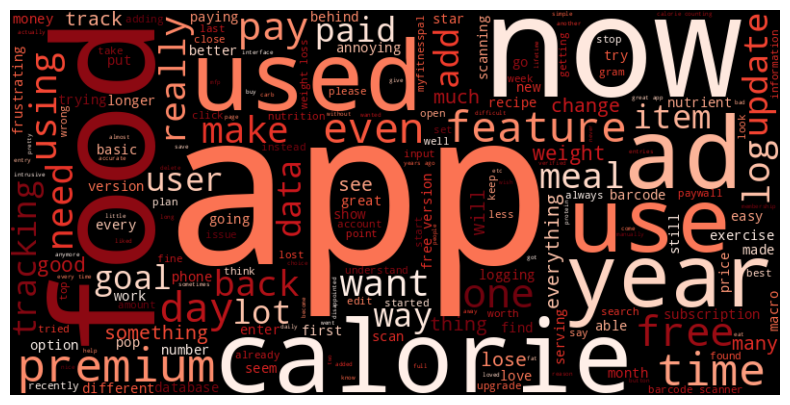

In [3]:
wordcloud_lo = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(reviews_lo)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_lo, interpolation='bilinear')
plt.axis('off')
plt.show()
wordcloud_lo.to_file('outputs/wordcloud_lo_en.png')

There is high frequency of words like:
- ads
- paywall
- subscription

## Word Cloud: Positive Reviews (4+ stars)

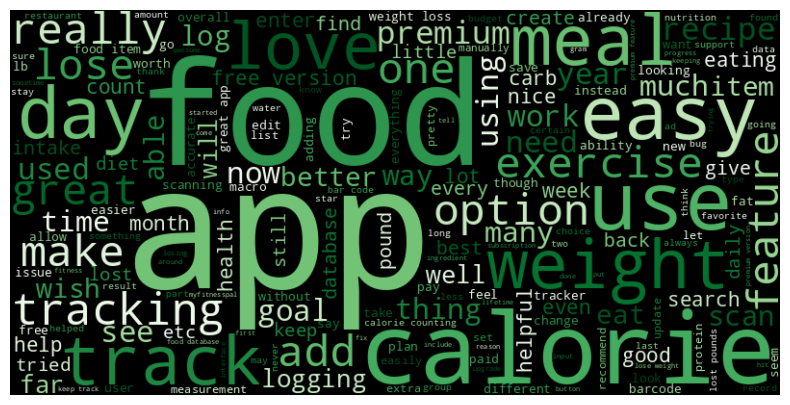

In [4]:
wordcloud_hi = WordCloud(
    width=800, height=400, background_color='black', colormap='Greens'
    ).generate(reviews_hi)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_hi, interpolation='bilinear')
plt.axis('off')
plt.show()
wordcloud_hi.to_file('outputs/wordcloud_hi_en.png')

High Frequency:
- calorie
- tracking
- easy
- exercise
- goal
- meal

## Top Relevant Negative Reviews

In [5]:
import textwrap

df_lo = df_lo.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_negative_reviews = df_lo['content'].head(10).tolist()

def show_reviews(reviews:list):
    for i in range(len(reviews)):
        wrapped = textwrap.fill(f'review {i+1}: {reviews[i]}', width=100)
        print(wrapped)
        print()

show_reviews(most_relevant_negative_reviews)

review 1: This is not an ad-supported or free version, but only a free trial. Users should be told
up-front, before bothering to download, before the app does its data gathering, that the 'free'
version is only a 7 day trial, after which it will automatically charge $39 a year. No scummier than
most apps, but that's a low bar. If you're into being manipulated, the graphics look good, and a lot
of thought went into the process of making the user feel comfy about it.

review 2: I used to love this app and recommend it. In the last 3 weeks the pop up ads have gotten
so frequent I can't stand it anymore. On top of that, the ads have become videos that you CANNOT
stop and close. That was it for me. I understand the ad supported model, but it's now crossed the
line to be so annoying I am moving to a competitor. Edit - the auto-bot reply was how to pay to stop
the ads. It's clear they do not value the customer experience unless you pay. Too bad.

review 3: WARNING: Pop-Up ads will take over y

### Notes:
- Replace with app-specific findings after reviewing the printed negative reviews.

## Top Relevant Positive Reviews

In [6]:
df_hi = df_hi.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_positive_reviews = df_hi['content'].head(10).tolist()

show_reviews(most_relevant_positive_reviews)

review 1: I've been using Lose-It back and forth. I lose weight then I gain it and I come back. Each
time has gotten easier than the last, and this time I'm on pace to reach my goal with the assist of
exercise. The app has a lot of customization and plenty of features making it easy to use while also
providing a lot of features. Having premium is in my opinion worth it, as the extra tracking helped
me to reduce frequent cravings. overall it's a 10/10 for me. Beats any diet or cook book I've used.

review 2: The voice entry option is GREAT in the app. A lot of times knowing I can just rattle off
the things I remember eating for a meal and that it'll get them right (including amount) super quick
is a big thing that has kept me going. I DO pay for the premium version, but it also feels worth it.
They have a lifetime premium option as well if that is something you are looking for. This app has
grown a LOT since I had started using it about 15 years ago on an iPod touch 😁

review 3: I like 

### Notes:
- Replace with app-specific findings after reviewing the printed positive reviews.


# Arabic Reviews Word Cloud Analysis

In [7]:
import arabic_reshaper
from bidi.algorithm import get_display

df_arabic = pd.read_csv('data/google_reviews_ar.csv')
df_arabic['content_reshaped'] = df_arabic['content'].apply(
    lambda x: arabic_reshaper.reshape(str(x))
)

df_ar_lo = df_arabic[df_arabic['score']<4]
df_ar_hi = df_arabic[df_arabic['score']>=4]

## Arabic Word Cloud: Negative Reviews (< 4 stars)

In [8]:
def process_arabic(text):
    reshaped = arabic_reshaper.reshape(str(text))
    return reshaped

list_reviews_lo_ar = df_ar_lo['content'].apply(process_arabic)
list_reviews_hi_ar = df_ar_hi['content'].apply(process_arabic)

reviews_lo_ar = ' '.join(list_reviews_lo_ar)
reviews_hi_ar = ' '.join(list_reviews_hi_ar)

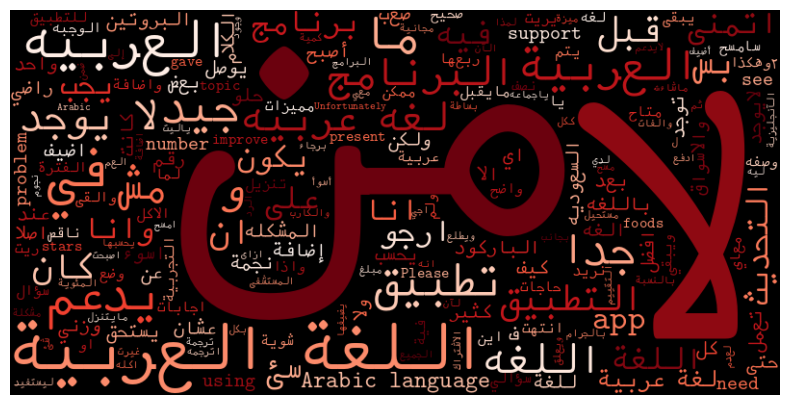

In [9]:
wordcloud_lo_ar = WordCloud(
    font_path='/usr/share/fonts/almfixed/almfixed.otf',
    width=800, 
    height=400, 
    background_color='black', 
    colormap='Reds',
).generate(reviews_lo_ar)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_lo_ar, interpolation='bilinear')
plt.axis('off')
plt.show()

wordcloud_lo_ar.to_file('outputs/wordcloud_lo_ar.png')

High Frequency:
- اللغة العربية
- لا يدعم
- التطبيق
- مشكلة
- تسجيل الدخول
- نسخة

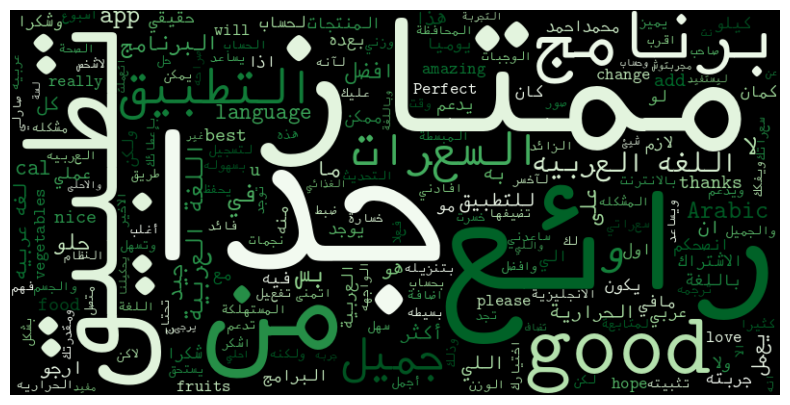

In [10]:
wordcloud_hi_ar = WordCloud(
    font_path='/usr/share/fonts/almfixed/almfixed.otf',
    width=800, 
    height=400, 
    background_color='black', 
    colormap='Greens',
).generate(reviews_hi_ar)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_hi_ar, interpolation='bilinear')
plt.axis('off')
plt.show()

wordcloud_hi_ar.to_file('outputs/wordcloud_hi_ar.png')

## Top Relevant Positive Arabic Reviews

In [11]:
df_ar_hi = df_ar_hi.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_positive_reviews_ar = df_ar_hi['content'].head(10).tolist()

show_reviews(most_relevant_positive_reviews_ar)

review 1: رائع جدا، ولكن ارجو اضافة اللغة العربية في اقرب وقت

review 2: البرنامج جداً ممتاز وانا استفدت منه كثير بس كمان عليه ملاحظات 1_ لا يدعم اللغه العربيه 2_
الاشتراك مافي شهري لازم سنوي ولا في تجربه مجانيه للمميزات الي تجي مع الاشتراك وشكراً

review 3: يرجى ان تضاف اللغه العربيه ليستفيد منه الجميع وشكرا

review 4: جميل جدا ولكن اتمنى توجد اللغه العربيه

review 5: ممتاز ويدعم اللغه العربيه في أغلب المنتجات

review 6: اذا سمحت اريد التطبيق باللغة العربية

review 7: يوجد مشكله مع التحديث الاخير لا يعمل البرنامج الا اذا كان متصل بالانترنت ارجو حل هذه
المشكله شكرا

review 8: ممتاز جدا لكن لا يدعم اللغة العربية

review 9: ينقصه اللغة العربية و يصبح 10/10

review 10: برنامج ممتاز لتسجيل السعرات المستهلكة يوميا ولكنه باللغة الانجليزية



## Top Relevant Negative Arabic Reviews

In [12]:
df_ar_lo = df_ar_lo.sort_values(by='thumbsUpCount', ascending=False)
most_relevant_negative_reviews_ar = df_ar_lo['content'].head(10).tolist()

show_reviews(most_relevant_negative_reviews_ar)

review 1: لمذا لا يوجد ترجمة للغة العربية ؟ ارجو اضافة اللغة العربية بجانب اللغة الإنجليزية ليستفيد
الجميع من البرامج

review 2: غيرت التقييم من 5 نجوم إلى نجمة، بكل بساطة لأن ميزة مسح الباركود كانت مجانية ثم الآن اصبحت
ضمن الاشتراك. مستحيل ادفع اي مبلغ عشان بس امسح باركود. وكان هذا اللي يميزهم عن التطبيقات الاخرى.
جاري البحث عن بديل.

review 3: برجاء إضافة اللغة العربية

review 4: لا يدعم اللغة العربيه

review 5: لا يدعم اللغة عربية

review 6: لا يدعم اللغة العربية

review 7: تطبيق جيد لاكن لا تتوفر الغه العربيه

review 8: لا يوجد لغة عربية واتمنى من اي واحد يقيمه يكتب هذه العبارة حتى يضيفوا اللغة العربية

review 9: يجب ان يدعم اللغه العربية😡😡😡

review 10: اتمنى أضافت اللغة العربية

